In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
# Load Dataset
data = pd.read_csv("cs_students.csv")


In [4]:
# Display first rows
data.head()

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


   Data Cleaning – Missing Values, Duplicates, Outliers

In [5]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


In [6]:
# Check missing values
print(data.isnull().sum())


Student ID           0
Name                 0
Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64


In [7]:
# Fill missing values
data.ffill(inplace=True)


In [8]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [9]:
# Remove extra spaces in column names
data.columns = data.columns.str.strip()


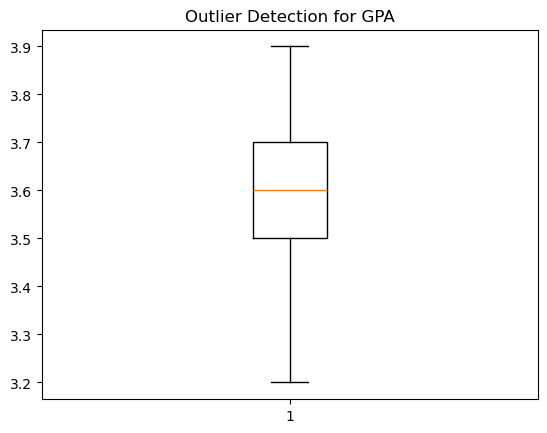

In [10]:
# Detect outliers (example CGPA)
plt.boxplot(data['GPA'])
plt.title("Outlier Detection for GPA")
plt.show()

In [44]:
useless_col = ['Student ID','Name','Major','Projects']
data.drop(columns = useless_col , inplace = True,errors='ignore')
data.head()

,Gender,Age,GPA,Interested Domain,Future Career,Python,SQL,Java
0,1,21,3.5,0,21,1,1,2
1,0,20,3.2,10,7,0,1,2
2,1,22,3.8,24,29,1,1,0
3,0,21,3.7,26,32,2,1,1
4,1,23,3.4,7,18,0,2,1


<Axes: xlabel='Age', ylabel='count'>

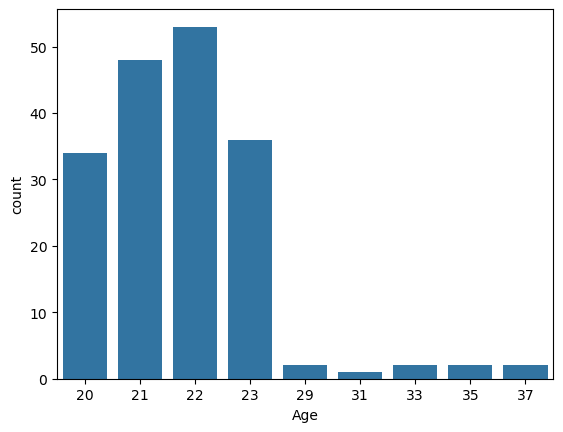

Exploratory Data Analysis (EDA)

In [11]:
# Statistical Summary
data.describe()

,Student ID,Age,GPA
count,180.000000,180.000000,180.000000
mean,90.500000,22.116667,3.615000
std,52.105662,2.823040,0.177341
min,1.000000,20.000000,3.200000
25%,45.750000,21.000000,3.500000
50%,90.500000,22.000000,3.600000
75%,135.250000,22.250000,3.700000
max,180.000000,37.000000,3.900000


Correlation Heatmap

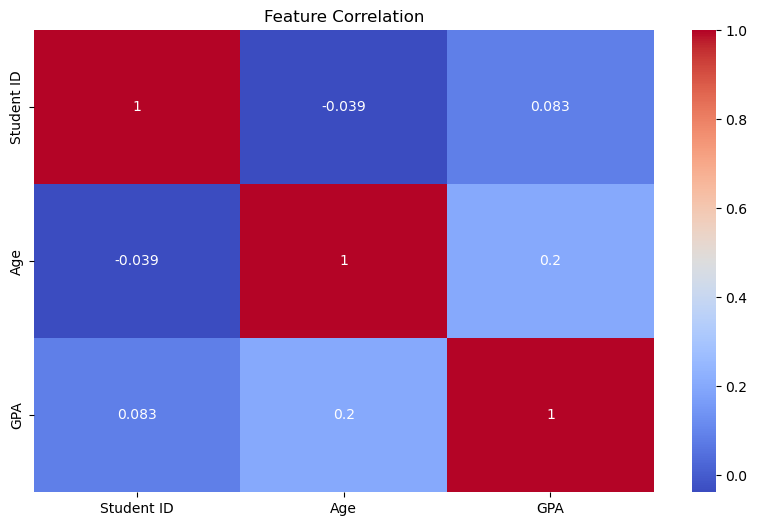

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Distribution Plot

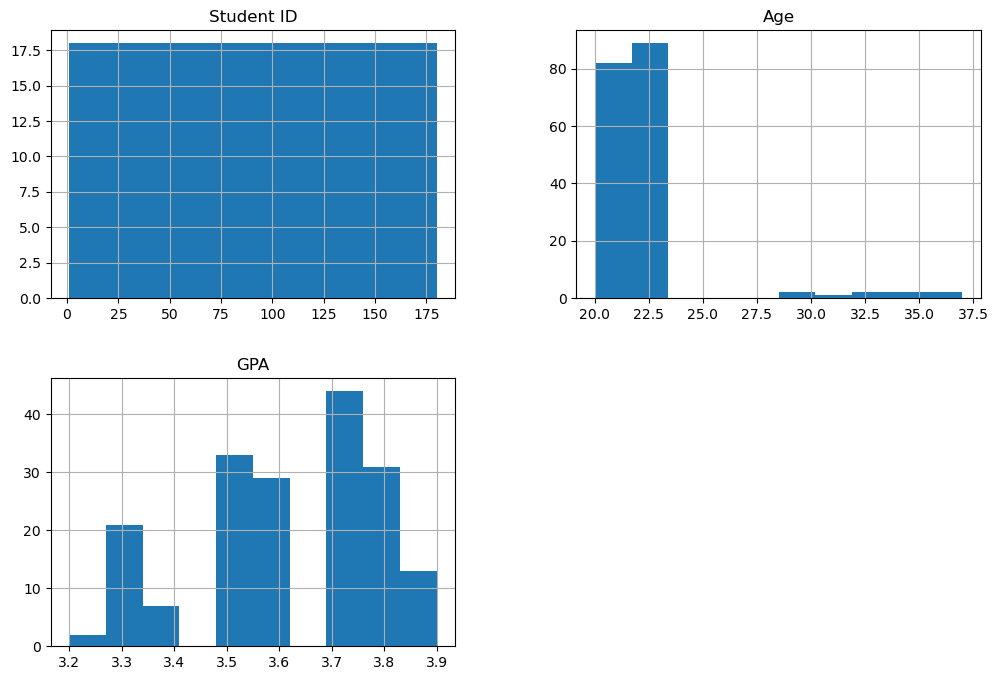

In [14]:
data.hist(figsize=(12,8))
plt.show()

Target Variable Distribution

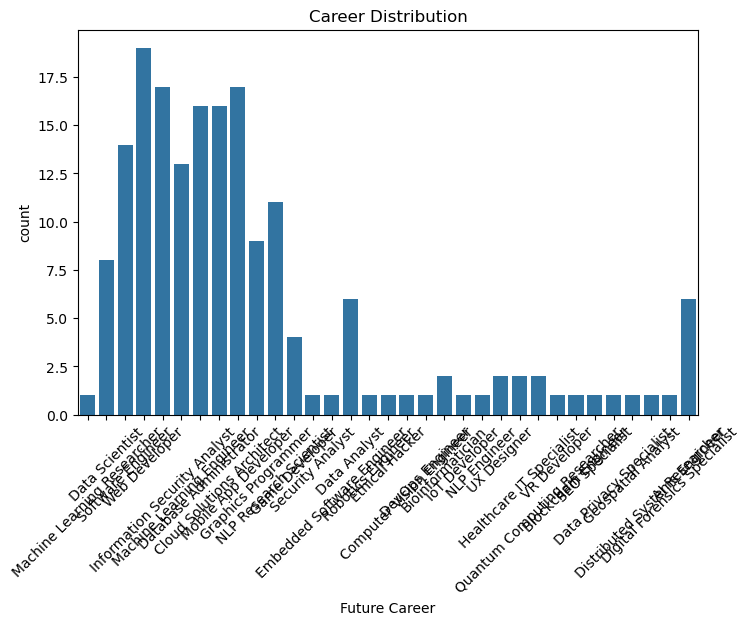

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x='Future Career', data=data)

plt.xticks(rotation=45)
plt.title("Career Distribution")
plt.show()


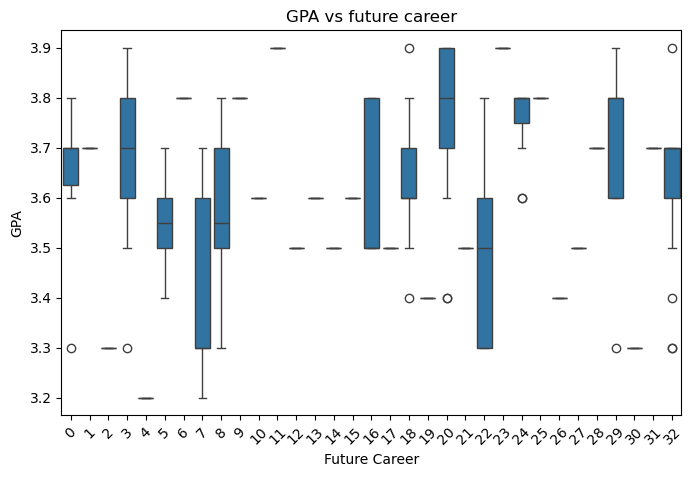

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Future Career', y='GPA', data=data)

plt.xticks(rotation=45)
plt.title("GPA vs future career")

plt.show()

Feature Engineering

In [26]:
encoder = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = encoder.fit_transform(data[col])

Feature Selection

In [27]:
X = data.drop("Future Career", axis=1)
y = data["Future Career"]


Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Feature Scaling

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

Logistic Regression

In [30]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Decision Tree

In [31]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

Random Forest

In [32]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

KNN

In [33]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

Gradient Boosting

In [35]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

Model Evaluation

In [36]:
print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Decision Tree:", accuracy_score(y_test, pred_dt))
print("Random Forest:", accuracy_score(y_test, pred_rf))
print("KNN:", accuracy_score(y_test, pred_knn))
print("Gradient Boosting:", accuracy_score(y_test, pred_gb))

Logistic Regression: 0.5555555555555556
Decision Tree: 0.8611111111111112
Random Forest: 0.7777777777777778
KNN: 0.3888888888888889
Gradient Boosting: 0.9166666666666666


Confusion Matrix

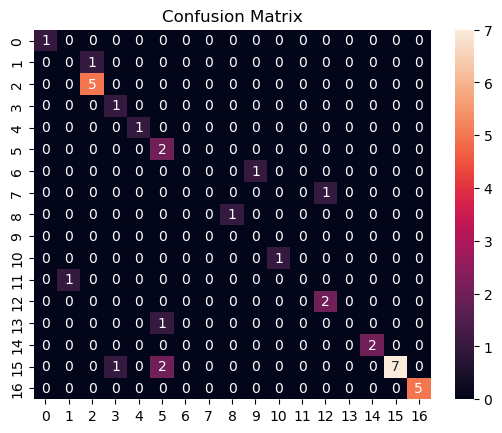

In [39]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Hyperparameter Tuning 

In [41]:
models = {
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "Decision Tree": accuracy_score(y_test, pred_dt),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "KNN": accuracy_score(y_test, pred_knn),
    "Gradient Boosting": accuracy_score(y_test, pred_gb),
    
}

best_model = max(models, key=models.get)

print("Best Model:", best_model)
print("Accuracy:", models[best_model])

Best Model: Gradient Boosting
Accuracy: 0.9166666666666666


In [53]:
import joblib

# Save model
joblib.dump(gb, "career_model.pkl")

# Load model
model = joblib.load("career_model.pkl")

# Predict
pred = model.predict(X_test)